# Homework 2 | Exploring Options | Tasks 1-4 due 09/22/25 | Task 5 due 09/24/25

Now that you have all of the options data stored locally on your computer and in pkl files, we can begin working with it. Your task will be to edit the monthly data and make some observations about its structure. See below.

## Tasks

### 1. For each file, remove the following columns: ['ImpliedVolatility', 'Delta','Gamma', 'Vega', 'Theta']

### 2. Add a column for the SPX index. MAKE SURE THE DATES MATCH! Hint: You might want to set the index of the options data to the date column... If yFinance doesn't let you download the SPX data skip this for now.

### 2. On paper or using markdown, use your knowledge of calculus to compute explicit formulas for the Greeks we discussed

### 3. Add columns of the Greeks using your formulae

### 4. Using the Newton Raphson method discussed on 9/17/25, calculate implied volatilies for each option and add this as a column to the data

### 5. Now plot the following and keep an eye out for specific relationships. We will talk about what we notice.

### 5.1 Using the ATM Strike and fixed date, plot the following:
* Call delta vs. time to maturity
* Call gamma vs. time to maturity
* Call theta vs. time to maturity
* Call vega vs. time to maturity
* Call implied volatility vs. time to maturity

Do the same for puts. What do you notice about the greeks for calls and puts?

### 5.2 From the span of 2015-2020:
* Calculate a 5,21,63,129 rolling realiezd volatilities for SPX
* Plot the implied volatilties for ATM options expiring at roughly the same 5,21,63,129 date marks. What I mean by this is, iterate through the data and calculate the implied volatility for ATM calls expriing in those times for every single day. You won't be using the same option for the 5 years if you get what I mean... Maybe it's clear already, and I'm being dramatic.
* Make some plots of IV - RV. What do you notice? When does the graph become positive?

### 5.3 Pick a date and maturity of your own choice and plot the following:
* Strike vs. delta
* Strike vs. theta
* Strike vs. IV
* Strike vs. option price

Feel free to do any additional analysis with the data at any time by the way. We are getting familiar with how options work here!

## Your work starts here

In [14]:
import numpy as np
import yfinance as yf
import os
import pandas as pd

# Download SPX data (last 30 years, daily)
SPX = yf.Ticker("^GSPC")
df_SPX = SPX.history(period="30y", interval="1d")
df_SPX.index = df_SPX.index.tz_localize(None)
close_series = df_SPX["Close"].round(3)

# PATHS

folder = "/Users/zakdjahed/Desktop/TAMID/Projects/2025-2026/OPPRCD_SPX/pickles"

# Columns to drop
drop_cols = ["ImpliedVolatility", "Delta", "Gamma", "Vega", "Theta"]

# Iterate over pickle files
for file in os.listdir(folder):
    if not file.endswith(".pkl"):
        continue

    file_path = os.path.join(folder, file)
    print(f"Processing: {file}")

    # Load pickle
    df = pd.read_pickle(file_path)

    # Parse the tab-delimited header line if needed
    if df.shape[1] == 1 and isinstance(df.iloc[0, 0], str) and "\t" in df.iloc[0, 0]:
        header_str = df.columns[0]
        new_columns = header_str.split("\t")
        df = df.iloc[:, 0].str.split("\t", expand=True)
        df.columns = new_columns

    # Parse date column
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d", errors="coerce")
        df.set_index("Date", inplace=True)
    else:
        print(f"[warn] {file}: missing 'Date' column — skipped.")
        continue

    # Drop old Greek columns
    df = df.drop(columns=drop_cols, errors="ignore")

    # Add SPX column by reindexing the SPX close series
    df["SPX"] = close_series.reindex(df.index)

    # Save back to pickle
    df.to_pickle(file_path)
    print(f"✔ Updated {file} ({len(df)} rows)\n")

print("All done.")


Processing: SPX_OPTIONS_11012005.pkl
[warn] SPX_OPTIONS_11012005.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_11012011.pkl
[warn] SPX_OPTIONS_11012011.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_03012016.pkl
[warn] SPX_OPTIONS_03012016.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_03012002.pkl
[warn] SPX_OPTIONS_03012002.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_12012019.pkl
[warn] SPX_OPTIONS_12012019.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_06012019.pkl
[warn] SPX_OPTIONS_06012019.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_05012011.pkl
[warn] SPX_OPTIONS_05012011.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_05012005.pkl
[warn] SPX_OPTIONS_05012005.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_08012012.pkl
[warn] SPX_OPTIONS_08012012.pkl: missing 'Date' column — skipped.
Processing: SPX_OPTIONS_08012006.pkl
[warn] SPX_OPTIONS_08012006.pkl: mis

In [15]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import newton, brentq
import pandas as pd
import os

# CONFIG
r = 0.045          # risk-free rate (4.5% is reasonable to me)
sigma = 0.2        # initial vol guess
folder = "/Users/zakdjahed/Desktop/TAMID/Projects/2025-2026/OPPRCD_SPX/pickles"  

# Black–Scholes
def d1_d2(S, K, T, r, sigma):
    sigma = np.clip(sigma, 1e-8, 5.0)
    T = np.maximum(T, 1e-8)
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2

def black_scholes_price(S, K, T, r, sigma, option_type='C'):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    if option_type == "C":
        return (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
    else:
        return (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))

# Greeks
def delta(S, K, T, r, sigma, option_type='C'):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return norm.cdf(d1) if option_type == 'C' else norm.cdf(d1) - 1

def gamma(S, K, T, r, sigma):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta(S, K, T, r, sigma, option_type='C'):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    first = - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    if option_type == 'C':
        return first - r * K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return first + r * K * np.exp(-r * T) * norm.cdf(-d2)

def vega(S, K, T, r, sigma):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

def inflexion_point(S, K, T, r):
    m = S / (K * np.exp(-r * T))
    return np.sqrt(2 * abs(np.log(m) / T))

# Implied Volatility (Newton with Brent fallback)
def implied_vol_newton(S, K, T, r, market_price, option_type='C',
                       sigma_init=0.2, tol=1e-8, maxiter=100,
                       sigma_min=1e-8, sigma_max=5.0):

    try:
        S = float(S); K = float(K); T = float(T); market_price = float(market_price)
    except Exception:
        return -99.99

    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(market_price):
        return -99.99

    # No-arbitrage bounds
    discK = K * np.exp(-r * T)
    if option_type.upper().startswith('C'):
        lower = max(0.0, S - discK)
        upper = S
    else:
        lower = max(0.0, discK - S)
        upper = discK

    if (market_price < lower - 1e-12) or (market_price > upper + 1e-12):
        return -99.99
    if np.isclose(market_price, lower, atol=1e-12) or np.isclose(market_price, upper, atol=1e-12):
        return sigma_min

    def f(sigma):
        return black_scholes_price(S, K, T, r, sigma, option_type) - market_price

    def fprime(sigma):
        v = vega(S, K, T, r, sigma)
        if not np.isfinite(v) or v == 0.0:
            raise RuntimeError("invalid vega")
        return v

    x0 = float(np.clip(sigma_init, sigma_min, sigma_max))
    try:
        iv = newton(f, x0=x0, fprime=fprime, tol=tol, maxiter=maxiter)
        if not np.isfinite(iv) or iv < sigma_min or iv > sigma_max:
            raise RuntimeError("sigma out of bounds")
        return iv
    except Exception:
        try:
            return brentq(f, sigma_min, sigma_max)
        except Exception:
            # print(f"No IV for S={S}, K={K}, T={T}, price={market_price}, type={option_type}")
            return -99.99

# Main loop over pickles
for file_i, file in enumerate(sorted(os.listdir(folder)), start=1):
    if not file.endswith(".pkl"):
        continue

    file_path = os.path.join(folder, file)
    print(f"\n=== [{file_i}] Processing file: {file} ===")
    df = pd.read_pickle(file_path)
    print(f"Loaded {len(df):,} rows")

    # Ensure these columns are numeric if present
    for c in ["SPX", "Strike", "BestBid", "BestOffer"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Dates & time to expiry
    # If previous block did not set index to trade date, uncomment the next two lines:
    # df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d", errors="coerce")
    # df = df.set_index("Date")

    df["Expiration"] = pd.to_datetime(df["Expiration"].astype(str), format="%Y%m%d", errors="coerce")
    df["T"] = (df["Expiration"] - df.index).dt.days / 365.0
    df["T"] = df["T"].clip(lower=1e-8)
    df["DaysToExpiration"] = df["T"] * 365.0
    df["Mid"] = (df["BestBid"] + df["BestOffer"]) / 2.0

    # Vector of inputs
    S_arr    = df["SPX"].values
    K_arr    = df["Strike"].values
    T_arr    = df["T"].values
    Mid_arr  = df["Mid"].values
    Type_arr = df["CallPut"].astype(str).values

    # Implied volatilities
    print("Calculating implied volatilities...")
    df["ImpliedVolatility"] = [
        implied_vol_newton(S, K, T, r, Mid, opt_type)
        for S, K, T, Mid, opt_type in zip(S_arr, K_arr, T_arr, Mid_arr, Type_arr)
    ]

    # Greeks (computed separately for calls and puts)
    print("Computing Greeks...")
    for cp in ["C", "P"]:
        mask = df["CallPut"] == cp
        S = df.loc[mask, "SPX"]
        K = df.loc[mask, "Strike"]
        T = df.loc[mask, "T"]
        sigma_vec = df.loc[mask, "ImpliedVolatility"]

        bad = (sigma_vec == -99.99)

        df.loc[mask, "BlackScholes"] = np.where(bad, -99.99, black_scholes_price(S, K, T, r, sigma_vec, cp))
        df.loc[mask, "Delta"]        = np.where(bad, -99.99, delta(S, K, T, r, sigma_vec, cp))
        df.loc[mask, "Theta"]        = np.where(bad, -99.99, theta(S, K, T, r, sigma_vec, cp))

    # Gamma & Vega (same for calls/puts)
    S = df["SPX"]; K = df["Strike"]; T = df["T"]; sigma_vec = df["ImpliedVolatility"]
    bad = (sigma_vec == -99.99)
    df["Gamma"] = np.where(bad, -99.99, gamma(S, K, T, r, sigma_vec))
    df["Vega"]  = np.where(bad, -99.99, vega(S, K, T, r, sigma_vec))

    # Save back
    df.to_pickle(file_path)
    print(f"Finished file: {file}\n")

print("All done.")



=== [1] Processing file: SPX_OPTIONS_01011996.pkl ===
Loaded 5,580 rows
Calculating implied volatilities...
Computing Greeks...
Finished file: SPX_OPTIONS_01011996.pkl


=== [2] Processing file: SPX_OPTIONS_01011997.pkl ===
Loaded 8,378 rows
Calculating implied volatilities...
Computing Greeks...
Finished file: SPX_OPTIONS_01011997.pkl


=== [3] Processing file: SPX_OPTIONS_01011998.pkl ===
Loaded 8,745 rows
Calculating implied volatilities...


/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_zeros_py.py:326: RuntimeWarning: overflow encountered in scalar divide
  newton_step = fval / fder


Computing Greeks...
Finished file: SPX_OPTIONS_01011998.pkl


=== [4] Processing file: SPX_OPTIONS_01011999.pkl ===
Loaded 8,654 rows
Calculating implied volatilities...


/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_zeros_py.py:326: RuntimeWarning: overflow encountered in scalar divide
  newton_step = fval / fder


Computing Greeks...
Finished file: SPX_OPTIONS_01011999.pkl


=== [5] Processing file: SPX_OPTIONS_01012000.pkl ===
Loaded 10,584 rows
Calculating implied volatilities...


...

Computing Greeks...
Finished file: SPX_OPTIONS_12012020.pkl


=== [333] Processing file: SPX_OPTIONS_12012021.pkl ===
Loaded 502,027 rows
Calculating implied volatilities...


/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_zeros_py.py:326: RuntimeWarning: overflow encountered in scalar divide
  newton_step = fval / fder


Computing Greeks...
Finished file: SPX_OPTIONS_12012021.pkl


=== [334] Processing file: SPX_OPTIONS_12012022.pkl ===
Loaded 402,756 rows
Calculating implied volatilities...


/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_zeros_py.py:326: RuntimeWarning: overflow encountered in scalar divide
  newton_step = fval / fder


Computing Greeks...
Finished file: SPX_OPTIONS_12012022.pkl

✅ All done.


Using file: /Users/zakdjahed/Desktop/TAMID/Projects/2025-2026/OPPRCD_SPX/pickles/SPX_OPTIONS_02012023.pkl
Strikes appear scaled by 1000; dividing by 1000 for this plot.
Requested strike 4000.0, using nearest available 4000.0


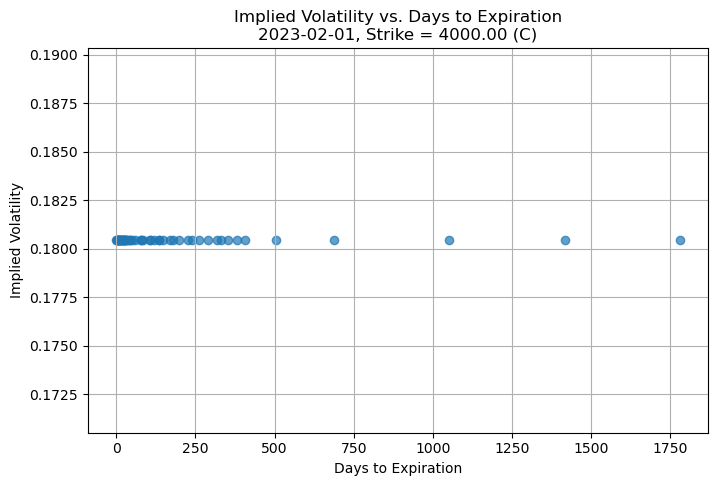

In [21]:
import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import newton, brentq

# Black–Scholes helpers (q = 0) 
R = 0.045

def d1_d2(S, K, T, r, sigma):
    sigma = np.clip(np.asarray(sigma, float), 1e-8, 5.0)
    T = np.maximum(np.asarray(T, float), 1e-8)
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2

def bs_price(S, K, T, r, sigma, call=True):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    if call:
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def vega(S, K, T, r, sigma):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

def iv_solve_row(S, K, T, r, mkt, call=True, x0=0.2):
    # bounds & quick rejects
    discK = K * np.exp(-r*T)
    lb = max(0.0, S - discK) if call else max(0.0, discK - S)
    ub = S if call else discK
    if not np.isfinite(S*K*T*mkt) or mkt < lb - 1e-12 or mkt > ub + 1e-12:
        return np.nan
    if np.isclose(mkt, lb, atol=1e-12) or np.isclose(mkt, ub, atol=1e-12):
        return 1e-8

    def f(s):  return bs_price(S,K,T,r,s,call) - mkt
    def fp(s): return vega(S,K,T,r,s)

    try:
        iv = newton(f, x0=np.clip(x0, 1e-8, 5.0), fprime=fp, tol=1e-8, maxiter=100)
        if 1e-8 <= iv <= 5.0 and np.isfinite(iv): return iv
        raise RuntimeError
    except Exception:
        try:    return brentq(f, 1e-8, 5.0)
        except Exception:
            return np.nan

# Setup
FOLDER = "/Users/zakdjahed/Desktop/TAMID/Projects/2025-2026/OPPRCD_SPX/pickles"
candidates = sorted(glob.glob(os.path.join(FOLDER, "*202302*.pkl"))) or \
             sorted(glob.glob(os.path.join(FOLDER, "*02012023*.pkl"))) or \
             sorted(glob.glob(os.path.join(FOLDER, "*.pkl")))
file_name = candidates[0]
print("Using file:", file_name)

# Params
DESIRED_STRIKE = 4000.0
DATE = pd.Timestamp("2023-02-01")
option_type = "C"  # or "P"

# Load
df = pd.read_pickle(file_name)

# Ensure Date index
if not isinstance(df.index, pd.DatetimeIndex):
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d", errors="coerce")
        df = df.set_index("Date")
    else:
        raise KeyError("No datetime index and no 'Date' column found.")

# Numeric cleanup
for c in ["Strike", "BestBid", "BestOffer", "SPX", "SPX_AdjClose", "T", "DaysToExpiration"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Strike unit fix ONLY for this plotting math
if "Strike" in df.columns and np.nanmedian(df["Strike"]) > 100000:
    print("Strikes appear scaled by 1000; dividing by 1000 for this plot.")
    df["Strike"] = df["Strike"] / 1000.0

# Build Mid / DaysToExpiration if missing
if "Mid" not in df.columns and {"BestBid","BestOffer"}.issubset(df.columns):
    df["Mid"] = (df["BestBid"] + df["BestOffer"]) / 2.0
if "DaysToExpiration" not in df.columns:
    if "T" in df.columns and df["T"].notna().any():
        df["DaysToExpiration"] = df["T"] * 365.0
    else:
        exp = pd.to_datetime(df["Expiration"].astype(str), format="%Y%m%d", errors="coerce")
        df["DaysToExpiration"] = (exp - df.index).days

# Choose spot column
S_COL = "SPX_AdjClose" if "SPX_AdjClose" in df.columns else ("SPX" if "SPX" in df.columns else None)
if S_COL is None: raise KeyError("Neither SPX_AdjClose nor SPX column present.")
df[S_COL] = pd.to_numeric(df[S_COL], errors="coerce")

# Snapshot & nearest strike
snap = df.loc[df.index == DATE].copy()
if snap.empty:
    raise ValueError(f"No rows for {DATE.date()} in {os.path.basename(file_name)}")

nearest_strike = snap["Strike"].iloc[(snap["Strike"] - DESIRED_STRIKE).abs().argsort()].iloc[0]
print(f"Requested strike {DESIRED_STRIKE}, using nearest available {nearest_strike}")

mask = (snap["CallPut"].astype(str).str.upper() == option_type) & np.isfinite(snap["Strike"]) & (snap["Strike"] == nearest_strike)
filtered = snap.loc[mask].copy()

# Drop sentinel IVs if present (but we'll recompute)
for col in ["ImpliedVolatility", "Delta", "Gamma", "Theta", "Vega"]:
    if col in filtered.columns:
        filtered[col] = pd.to_numeric(filtered[col], errors="coerce")

# Recompute IV just for these rows (correct K)
rows = []
for idx, row in filtered.iterrows():
    S   = row.get(S_COL, np.nan)
    K   = row.get("Strike", np.nan)
    T   = (row.get("DaysToExpiration", np.nan) / 365.0) if pd.notna(row.get("DaysToExpiration", np.nan)) else row.get("T", np.nan)
    mid = row.get("Mid", np.nan)
    cp  = str(row.get("CallPut", "C")).upper().startswith("C")
    iv  = iv_solve_row(S, K, T, R, mid, call=cp, x0=0.2)
    rows.append((idx, iv))
iv_fix = pd.Series({i:v for i,v in rows})
filtered["IV_recomputed"] = iv_fix

# Plot
metrics = {"IV_recomputed":"Implied Volatility"}  # add Greeks later if you also recompute with correct K
ok = filtered[["DaysToExpiration", "IV_recomputed"]].dropna()
plt.figure(figsize=(8,5))
if not ok.empty:
    plt.scatter(ok["DaysToExpiration"], ok["IV_recomputed"], alpha=0.7)
    x_min, x_max = ok["DaysToExpiration"].min(), ok["DaysToExpiration"].max()
    if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
        x_pad = (x_max - x_min) * 0.05
        plt.xlim(x_min - x_pad, x_max + x_pad)
    y_min, y_max = ok["IV_recomputed"].min(), ok["IV_recomputed"].max()
    if np.isfinite(y_min) and np.isfinite(y_max) and y_max > y_min:
        y_pad = (y_max - y_min) * 0.05
        plt.ylim(y_min - y_pad, y_max + y_pad)
else:
    print(f"Warning: no valid recomputed IVs for {DATE.date()} @ strike {nearest_strike}.")

plt.title(f"Implied Volatility vs. Days to Expiration\n{DATE.date()}, Strike = {nearest_strike:.2f} ({option_type})")
plt.xlabel("Days to Expiration")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.show()


Using file: /Users/zakdjahed/Desktop/TAMID/Projects/2025-2026/OPPRCD_SPX/pickles/SPX_OPTIONS_02012023.pkl
read df
Strikes appear scaled by 1000; dividing by 1000.
Requested strike 4000.0, using nearest available 4000.0


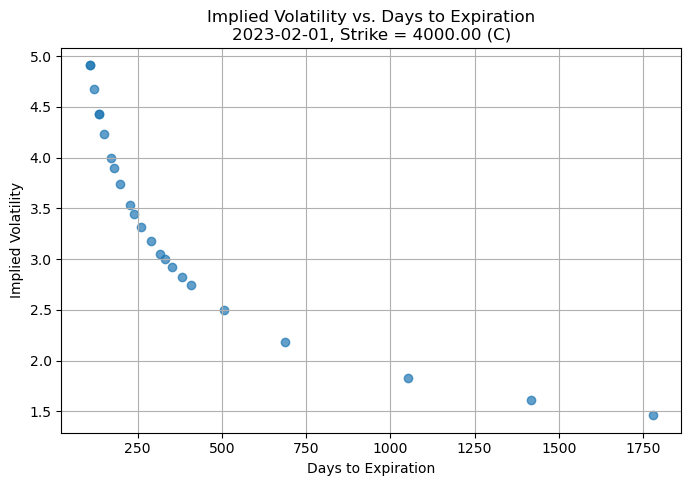

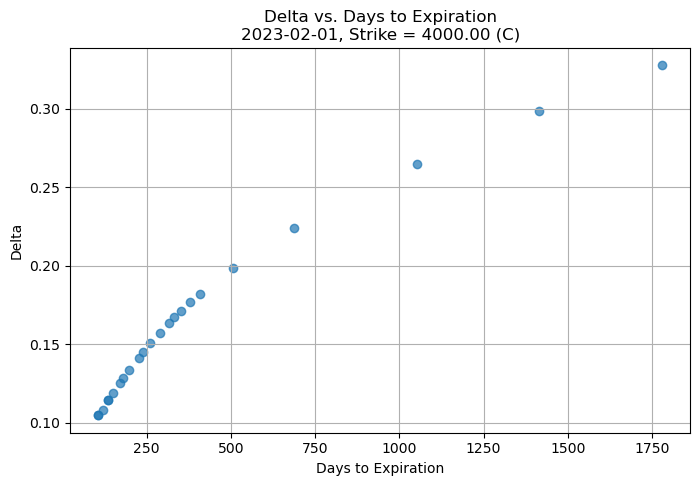

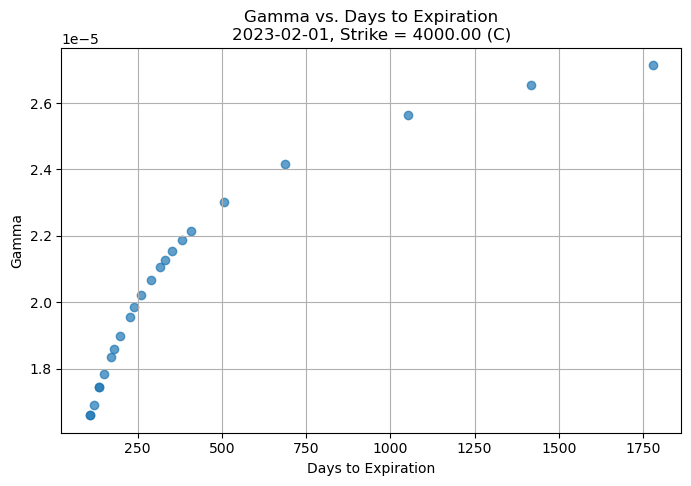

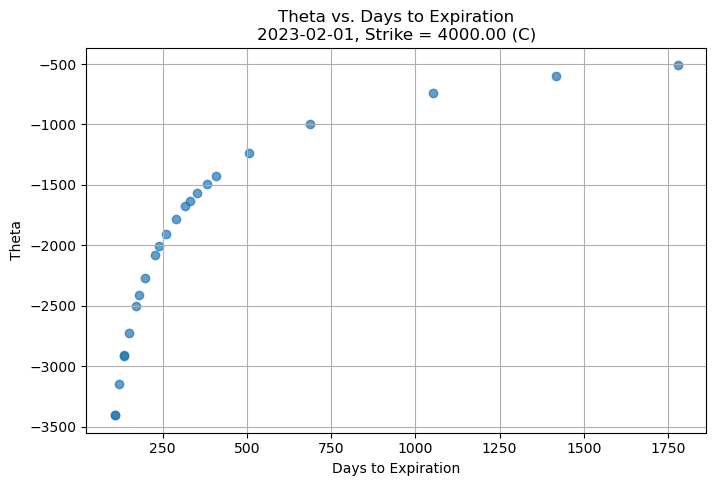

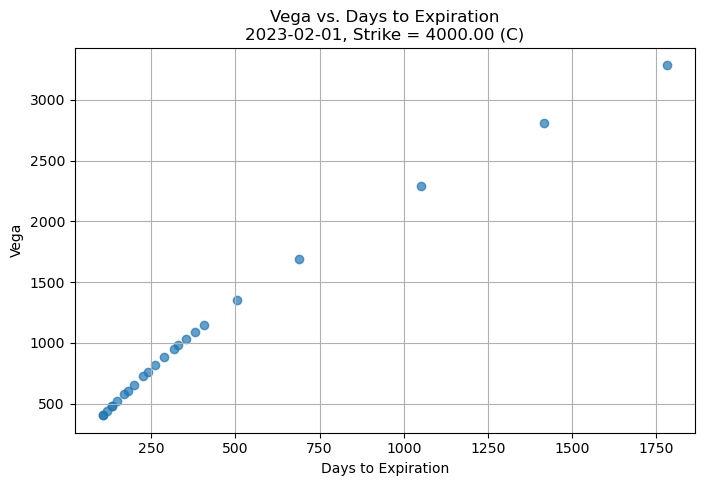

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config
FOLDER = "/Users/zakdjahed/Desktop/TAMID/Projects/2025-2026/OPPRCD_SPX/pickles"
# pick a file for Feb 2023 (
candidates = sorted(glob.glob(os.path.join(FOLDER, "*202302*.pkl"))) or \
             sorted(glob.glob(os.path.join(FOLDER, "*02012023*.pkl"))) or \
             sorted(glob.glob(os.path.join(FOLDER, "*.pkl")))
file_name = candidates[0]
print("Using file:", file_name)

df = pd.read_pickle(file_name)
print("read df")

# PARAMS
DESIRED_STRIKE = 4000.0
DATE = pd.Timestamp("2023-02-01")
option_type = "C"   # or "P"

# Ensure index is a proper trade date
if not isinstance(df.index, pd.DatetimeIndex):
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d", errors="coerce")
        df = df.set_index("Date")
    else:
        raise KeyError("No datetime index and no 'Date' column found.")

# Ensure required columns exist
for c in ["Strike", "BestBid", "BestOffer"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Strike unit fix (auto-detect millidollars -> divide by 1000)
if "Strike" in df.columns:
    med_strike = float(np.nanmedian(df["Strike"]))
    if np.isfinite(med_strike) and med_strike > 100000: 
        print("Strikes appear scaled by 1000; dividing by 1000.")
        df["Strike"] = df["Strike"] / 1000.0

# Compute DaysToExpiration if missing
if "DaysToExpiration" not in df.columns:
    if "T" in df.columns:
        df["DaysToExpiration"] = pd.to_numeric(df["T"], errors="coerce") * 365.0
    else:
        if "Expiration" not in df.columns:
            raise KeyError("Neither 'T' nor 'Expiration' present to compute DaysToExpiration.")
        exp = pd.to_datetime(df["Expiration"].astype(str), format="%Y%m%d", errors="coerce")
        df["DaysToExpiration"] = (exp - df.index).days

# Clean invalid IV/Greeks rows (your friend used -99.99 sentinel)
for col in ["ImpliedVolatility", "Delta", "Gamma", "Theta", "Vega"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Pick the nearest strike available on that date (more robust than exact float match)
snap = df.loc[df.index == DATE].copy()
if snap.empty:
    raise ValueError(f"No rows found for trade date {DATE.date()} in {os.path.basename(file_name)}")

if "Strike" not in snap.columns:
    raise KeyError("'Strike' column missing.")

nearest_strike = snap["Strike"].iloc[(snap["Strike"] - DESIRED_STRIKE).abs().argsort()].iloc[0]
print(f"Requested strike {DESIRED_STRIKE}, using nearest available {nearest_strike}")

# Filter to the chosen date/type/strike and drop sentinel values
filtered = snap[(snap["CallPut"].astype(str).str.upper() == option_type) &
                (np.isfinite(snap["Strike"])) &
                (snap["Strike"] == nearest_strike)].copy()

for col in ["ImpliedVolatility", "Delta", "Gamma", "Theta", "Vega"]:
    if col in filtered.columns:
        filtered = filtered[filtered[col] != -99.99]

filtered["DaysToExpiration"] = pd.to_numeric(filtered["DaysToExpiration"], errors="coerce")

# Pretty labels for plotting
metrics = {
    "ImpliedVolatility": "Implied Volatility",
    "Delta": "Delta",
    "Gamma": "Gamma",
    "Theta": "Theta",
    "Vega": "Vega",
}

# Plot each metric vs DaysToExpiration
for col, title in metrics.items():
    if col not in filtered.columns:
        print(f"Warning: column '{col}' not found — skipping plot.")
        continue

    plt.figure(figsize=(8, 5))
    ok = filtered[["DaysToExpiration", col]].dropna()
    if not ok.empty:
        plt.scatter(ok["DaysToExpiration"], ok[col], alpha=0.7)

        x_min, x_max = ok["DaysToExpiration"].min(), ok["DaysToExpiration"].max()
        if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
            x_pad = (x_max - x_min) * 0.05
            plt.xlim(x_min - x_pad, x_max + x_pad)

        y_min, y_max = ok[col].min(), ok[col].max()
        if np.isfinite(y_min) and np.isfinite(y_max) and y_max > y_min:
            y_pad = (y_max - y_min) * 0.05
            plt.ylim(y_min - y_pad, y_max + y_pad)
    else:
        print(f"Warning: no valid data for {title} on {DATE.date()} @ strike {nearest_strike}.")

    plt.title(f"{title} vs. Days to Expiration\n{DATE.date()}, Strike = {nearest_strike:.2f} ({option_type})")
    plt.xlabel("Days to Expiration")
    plt.ylabel(title)
    plt.grid(True)
    plt.show()


In [23]:
df["Strike"].describe()


count    350602.000000
mean       3814.494127
std         989.538123
min         100.000000
25%        3440.000000
50%        3915.000000
75%        4225.000000
max       12000.000000
Name: Strike, dtype: float64